# Libraries

In [40]:
library(deSolve)
library(ggplot2)
library(dplyr)
library(tidyr)
library(R.matlab)

## General variables

In [ ]:
# Populations
age_groups  <- c("[0-10]","[10-20]","[20-30]","[30-40]",
                 "[40-50]","[50-60]","[60-70]","[70-80]","80+")
Ng          <- length(age_groups)
pop_distr   <- c(9.2, 9.6, 11.2, 12.8, 12.5, 16.2, 12.4, 9.1, 7.0)
pop_weights <- pop_distr / sum(pop_distr)


# Load matrix and extract parameters
mat_path   <- "/home/elodie/Documents/projects/aoetia/MiTepid_sim/mitepid/Optimised_B/B_opt_SEIR_Ti_5_R0_2.95.mat"
mat        <- readMat(mat_path)
B_opt_norm <- mat$B.opt

extract_diag <- function(x) {
  x <- drop(x)
  if (is.matrix(x)) diag(x) else as.vector(x)
}
Gamma_diag <- diag(extract_diag(mat$Gamma))
Sigma_diag <- diag(extract_diag(mat$Sigma))
D          <- Gamma_diag   # Mu = 0

# Germany uncontained contact matrix
B_factors     <- outer(pop_distr, pop_distr, function(pi, pj) pj / pi)
B_uncontained <- B_opt_norm * B_factors

cat("R0 (Uncontained, Germany) =",
    round(max(abs(eigen(solve(D) %*% B_uncontained)$values)), 4), "\n")

# col index for each compartment in the ODE solution
I_cols_idx <- (2*Ng + 2):(3*Ng + 1)
R_cols_idx <- (3*Ng + 2):(4*Ng + 1)

# Initial conditions
x00 <- 1e-5
y0_standard <- c(rep(1 - x00, Ng),    # S
                 rep(0,        Ng),   # E
                 rep(x00,      Ng),   # I
                 rep(0,        Ng))   # R

# SEIR ODE system
seir_ode <- function(t, y, parms) {
  with(parms, {
    S <- y[1:Ng]
    E <- y[(Ng+1):(2*Ng)]
    I <- y[(2*Ng+1):(3*Ng)]
    R <- y[(3*Ng+1):(4*Ng)]
    
    foi <- B %*% I
    list(c(-S * foi,
            S * foi - Sigma %*% E,
            Sigma %*% E - D %*% I,
            Gamma_diag %*% I))
  })
}

# Run a single phase of the SEIR model
run_phase <- function(y0, t_start, t_end, B, dt = 0.1) {
  parms <- list(B = B, Sigma = Sigma_diag,
                Gamma_diag = Gamma_diag, D = D, Ng = Ng)
  sol   <- ode(y = y0, times = seq(t_start, t_end, by = dt),
               func = seir_ode, parms = parms, method = "lsoda")
  as.data.frame(sol)
}

# Population-weighted aggregation of a solution data frame
weighted_agg <- function(sol_df, col_idx) {
  as.vector(as.matrix(sol_df[, col_idx]) %*% pop_weights) * 100
}

# Scale contact matrix B by a vector of scaling factors
scale_B_opt <- function(B, scales) {
  s <- as.numeric(scales)
  for (i in seq_along(s)) B[i, ] <- B[i, ] * s[i]
  B
}

# shared ggplot theme
theme_mitepid <- function() {
  theme_bw(base_size = 11) +
  theme(
    panel.grid.major  = element_line(colour = "grey88", linewidth = 0.35),
    panel.grid.minor  = element_blank(),
    panel.border      = element_rect(colour = "grey60"),
    axis.ticks        = element_line(colour = "grey60"),
    legend.background = element_blank(),
    legend.key.height = unit(0.45, "cm"),
    legend.text       = element_text(size = 8, family = "mono"),
    plot.margin       = margin(10, 5, 5, 5)
  )
}


R0 (Uncontained, Germany) = 2.95 


# Figure 1 (a+b)

In [42]:
sol_s1 <- run_phase(y0_standard, 0, 211, B_uncontained)

colnames(sol_s1) <- c("time",
                       paste0("S_", seq_len(Ng)),
                       paste0("E_", seq_len(Ng)),
                       paste0("I_", seq_len(Ng)),
                       paste0("R_", seq_len(Ng)))

pal_viridis <- c("#fde725","#b5de2b","#6ece58","#35b779",
                 "#1f9e89","#26828e","#31688e","#3e4989","#440154")

pivot_by_age <- function(sol, prefix) {
  cols <- paste0(prefix, "_", seq_len(Ng))
  sol %>%
    select(time, all_of(cols)) %>%
    pivot_longer(-time, names_to = "idx", values_to = "value") %>%
    mutate(
      idx   = as.integer(sub(paste0(prefix, "_"), "", idx)),
      group = factor(age_groups[idx], levels = age_groups),
      value = value * 100
    )
}
sol_s1_I <- pivot_by_age(sol_s1, "I")
sol_s1_R <- pivot_by_age(sol_s1, "R")

sol_s1_I
sol_s1_R

time,idx,value,group
<dbl>,<int>,<dbl>,<fct>
0.0,1,0.0010000000,[0-10]
0.0,2,0.0010000000,[10-20]
0.0,3,0.0010000000,[20-30]
0.0,4,0.0010000000,[30-40]
0.0,5,0.0010000000,[40-50]
0.0,6,0.0010000000,[50-60]
0.0,7,0.0010000000,[60-70]
0.0,8,0.0010000000,[70-80]
0.0,9,0.0010000000,80+


time,idx,value,group
<dbl>,<int>,<dbl>,<fct>
0.0,1,0.000000e+00,[0-10]
0.0,2,0.000000e+00,[10-20]
0.0,3,0.000000e+00,[20-30]
0.0,4,0.000000e+00,[30-40]
0.0,5,0.000000e+00,[40-50]
0.0,6,0.000000e+00,[50-60]
0.0,7,0.000000e+00,[60-70]
0.0,8,0.000000e+00,[70-80]
0.0,9,0.000000e+00,80+


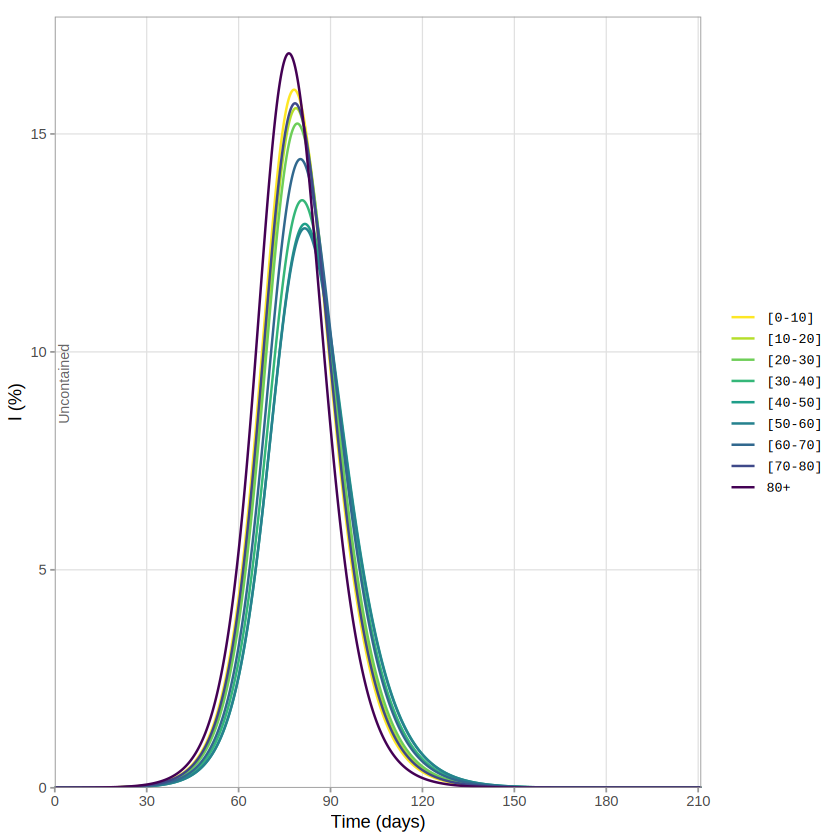

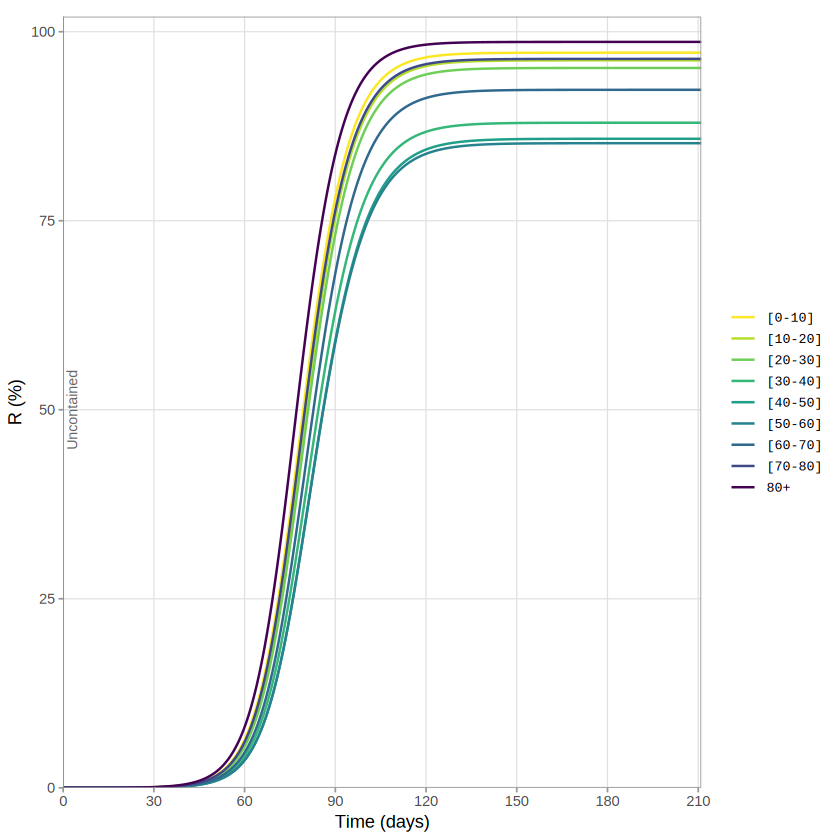

In [49]:
df <- pivot_by_age(sol_s1, "I")

ggplot(df, aes(x = time, y = value, colour = group)) +
  geom_line(linewidth = 0.7) +
  annotate("text", x = 3, y = max(df$value) * 0.55,
           label = "Uncontained", angle = 90, size = 3,
           colour = "grey40", hjust = 0.5) +
  scale_colour_manual(values = pal_viridis, name = NULL) +
  scale_x_continuous(breaks = seq(0, 210, 30), limits = c(0, 211), expand = c(0, 0)) +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.05))) +
  labs(x = "Time (days)", y = "I (%)") +
  theme_mitepid()

df <- pivot_by_age(sol_s1, "R")

ggplot(df, aes(x = time, y = value, colour = group)) +
  geom_line(linewidth = 0.7) +
  annotate("text", x = 3, y = 50, label = "Uncontained", angle = 90,
           size = 3, colour = "grey40", hjust = 0.5) +
  geom_vline(xintercept = 0, colour = "red", linewidth = 0.4) +
  scale_colour_manual(values = pal_viridis, name = NULL) +
  scale_x_continuous(breaks = seq(0, 210, 30), limits = c(0, 211), expand = c(0, 0)) +
  scale_y_continuous(limits = c(0, 100), expand = expansion(mult = c(0, 0.02))) +
  labs(x = "Time (days)", y = "R (%)") +
  theme_mitepid()


# Figure 2 (a+b)

In [43]:
# contact matrix scaling factors for different policies 
policy_scales <- list(
  UN   = c(1,   1,   1,   1,   1,   1,   1,   1,    1   ),
  KI   = c(0.2, 0.2, 1,   1,   1,   1,   1,   1,    1   ),
  EL   = c(1,   1,   1,   1,   1,   1,   1,   0.25, 0.25),
  KIEL = c(0.2, 0.2, 1,   1,   1,   1,   1,   0.25, 0.25),
  KIOF = c(0.2, 0.2, 0.5, 0.5, 0.5, 0.5, 0.5, 1,    1   ),
  ADEL = c(1,   1,   0.2, 0.2, 0.2, 0.2, 0.2, 0.25, 0.25),
  SD   = c(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.25, 0.25),
  LD   = c(0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,  0.1 )
)
policy_labels <- names(policy_scales)

t_switch      <- 60
t_end_s2      <- 211

list_I_s2 <- list()
list_R_s2 <- list()

for (i in seq_along(policy_labels)) {
  sol1     <- run_phase(y0_standard, 0, t_switch, B_uncontained)
  y1       <- unlist(sol1[nrow(sol1), -1])
  sol2     <- run_phase(y1, t_switch, t_end_s2,
                        scale_B_opt(B_uncontained, policy_scales[[i]]))
  sol_full <- bind_rows(sol1, sol2[-1, ])

  list_I_s2[[i]] <- weighted_agg(sol_full, I_cols_idx)
  list_R_s2[[i]] <- weighted_agg(sol_full, R_cols_idx)
}

t_seq_s2 <- seq(0, t_end_s2, by = 0.1)
pal_s2   <- c("#1B9E77","#D95F02","#7570B3","#E7298A",
              "#66A61E","#E6AB02","#A6761D","#666666")

make_df_policy <- function(lst) {
  do.call(bind_rows, lapply(seq_along(policy_labels), function(i)
    data.frame(time   = t_seq_s2,
               value  = lst[[i]],
               policy = factor(policy_labels[i], levels = policy_labels))))
}

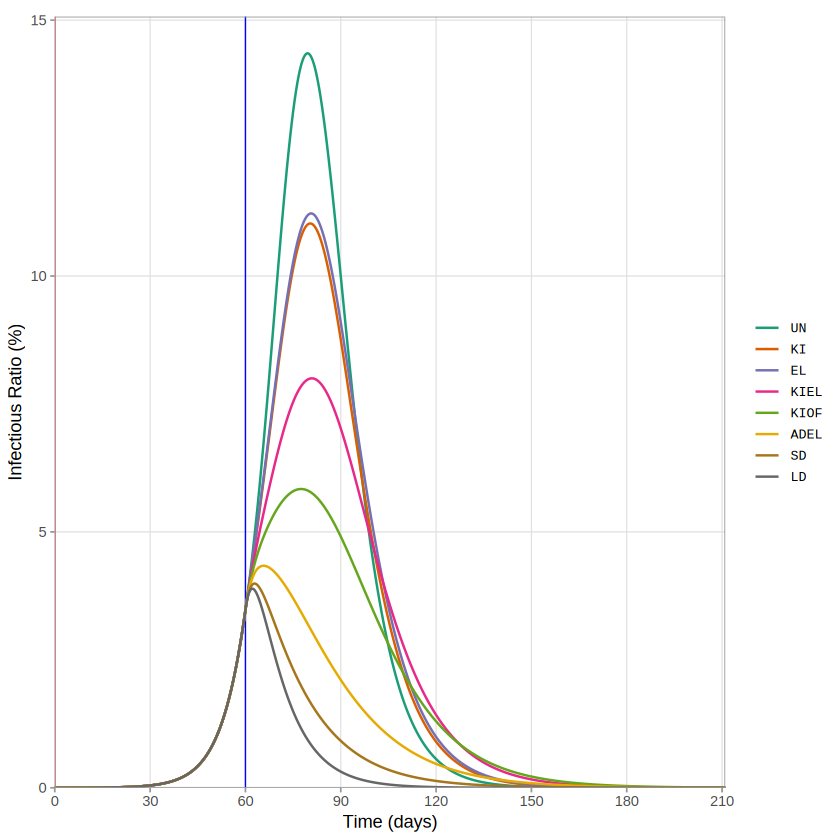

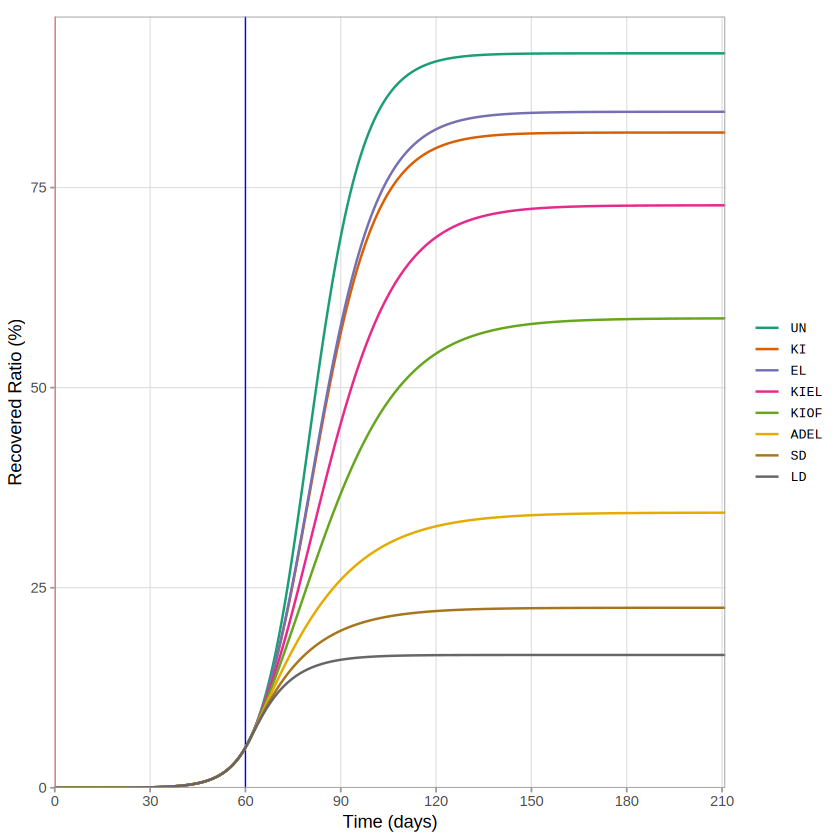

In [52]:
ggplot(make_df_policy(list_I_s2), aes(x = time, y = value, colour = policy)) +
  geom_vline(xintercept = 0,        colour = "red",  linewidth = 0.4) +
  geom_vline(xintercept = t_switch, colour = "blue", linewidth = 0.4) +
  geom_line(linewidth = 0.7) +
  scale_colour_manual(values = pal_s2, name = NULL) +
  scale_x_continuous(breaks = seq(0, 210, 30), limits = c(0, 211), expand = c(0, 0)) +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.05))) +
  labs(x = "Time (days)", y = "Infectious Ratio (%)") +
  theme_mitepid()

ggplot(make_df_policy(list_R_s2), aes(x = time, y = value, colour = policy)) +
  geom_vline(xintercept = 0,        colour = "red",  linewidth = 0.4) +
  geom_vline(xintercept = t_switch, colour = "blue", linewidth = 0.4) +
  geom_line(linewidth = 0.7) +
  scale_colour_manual(values = pal_s2, name = NULL) +
  scale_x_continuous(breaks = seq(0, 210, 30), limits = c(0, 211), expand = c(0, 0)) +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.05))) +
  labs(x = "Time (days)", y = "Recovered Ratio (%)") +
  theme_mitepid()

# Figure 4 (a+b+c+d)

In [44]:
x0I <- 1e-5
x0E <- 1e-5

# Two scenarios: list of named parameter sets
herd_scenarios <- list(
  Uncontained = list(
    B       = scale_B_opt(B_uncontained, rep(1, Ng)),
    t_end   = 540,
    pc1     = 56,          # fine-sweep starts here (herd immunity threshold %)
    label   = "Uncontained (R0 ≈ 2.95)"
  ),
  R0_is_1.5 = list(
    B       = scale_B_opt(B_uncontained, rep(1.5 / 2.95, Ng)),
    t_end   = 540,
    pc1     = 25,
    label   = "R0 = 1.5"
  )
)

# Verify R0 for each scenario
for (nm in names(herd_scenarios)) {
  sc  <- herd_scenarios[[nm]]
  rho <- max(abs(eigen(solve(D) %*% sc$B)$values))
  cat(sprintf("R0 (%s) = %.4f\n", nm, rho))
}

# Run all simulations, store results per scenario
herd_results <- lapply(herd_scenarios, function(sc) {
  pc1    <- sc$pc1
  x0R_v  <- c(seq(0, pc1 - 5, by = 5), seq(pc1, pc1 + 9, by = 1)) / 100
  labels <- paste0(round(x0R_v * 100), "%")
  times  <- seq(0, sc$t_end, by = 0.1)
  parms  <- list(B = sc$B, Sigma = Sigma_diag,
                 Gamma_diag = Gamma_diag, D = D, Ng = Ng)

  lst_I <- lst_R <- vector("list", length(x0R_v))

  for (i in seq_along(x0R_v)) {
    x0R  <- x0R_v[i]
    x0S  <- 1 - x0I - x0E - x0R
    y0   <- c(rep(x0S, Ng), rep(x0E, Ng), rep(x0I, Ng), rep(x0R, Ng))
    sol  <- as.data.frame(ode(y = y0, times = times, func = seir_ode,
                              parms = parms, method = "lsoda"))
    lst_I[[i]] <- weighted_agg(sol, I_cols_idx)
    lst_R[[i]] <- weighted_agg(sol, R_cols_idx)
  }

  pal <- colorRampPalette(
    c("#2166AC","#92C5DE","#F7F7F7","#F4A582","#D6604D"))(length(x0R_v))

  make_df <- function(lst) {
    do.call(rbind, lapply(seq_along(labels), function(i)
      data.frame(time  = times,
                 value = lst[[i]],
                 label = factor(labels[i], levels = labels))))
  }

  list(df_I = make_df(lst_I), df_R = make_df(lst_R),
       pal = pal, t_end = sc$t_end, main_label = sc$label)
})


R0 (Uncontained) = 2.9500
R0 (R0_is_1.5) = 1.5000


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Uncontained (R0 ≈ 2.95)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Uncontained (R0 ≈ 2.95)' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Uncontained (R0 ≈ 2.95)' in 'mbcsToSbcs': dot substituted for <88>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Uncontained (R0 ≈ 2.95)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Uncontained (R0 ≈ 2.95)' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Uncontained (R0

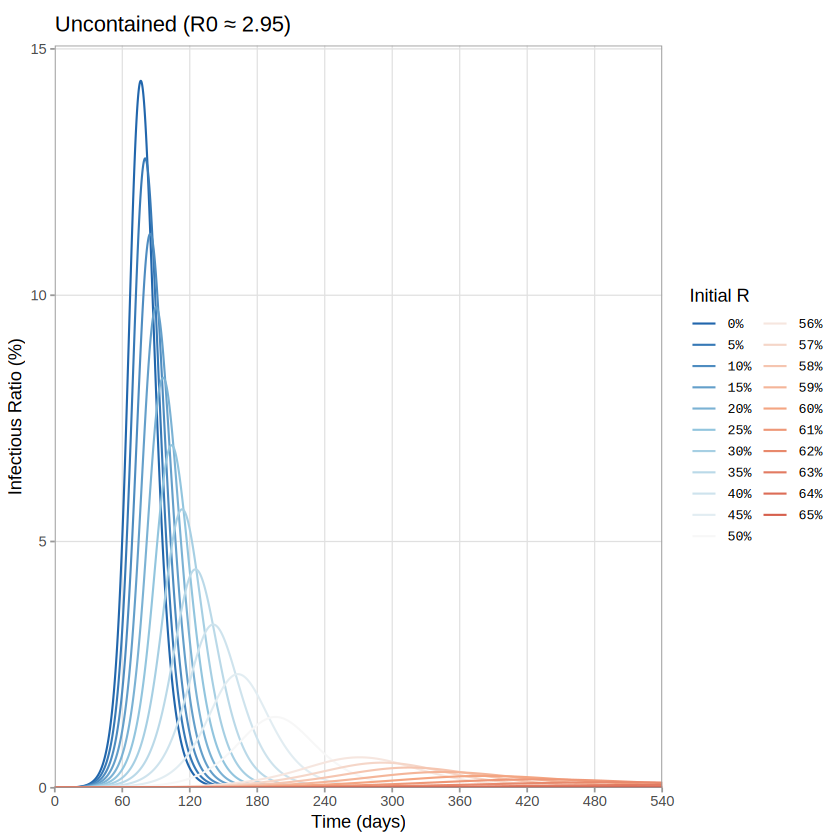

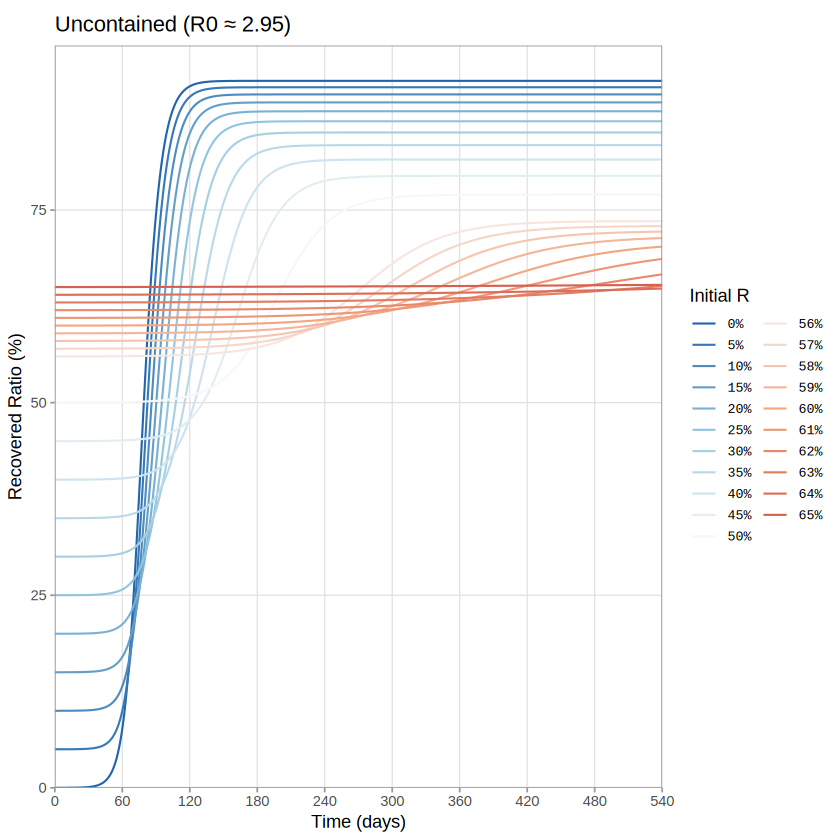

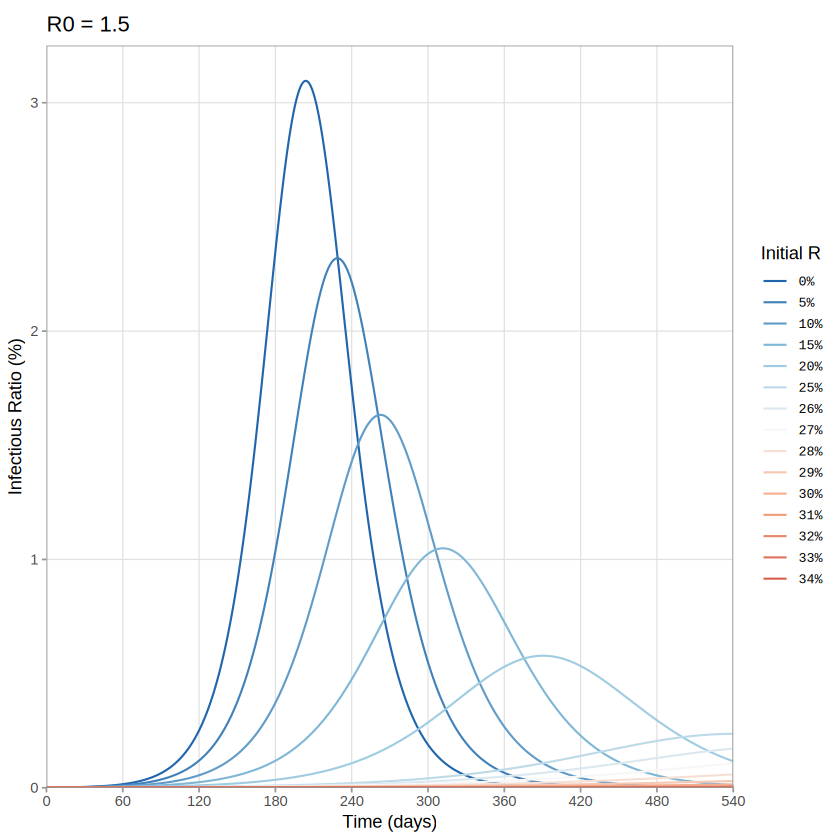

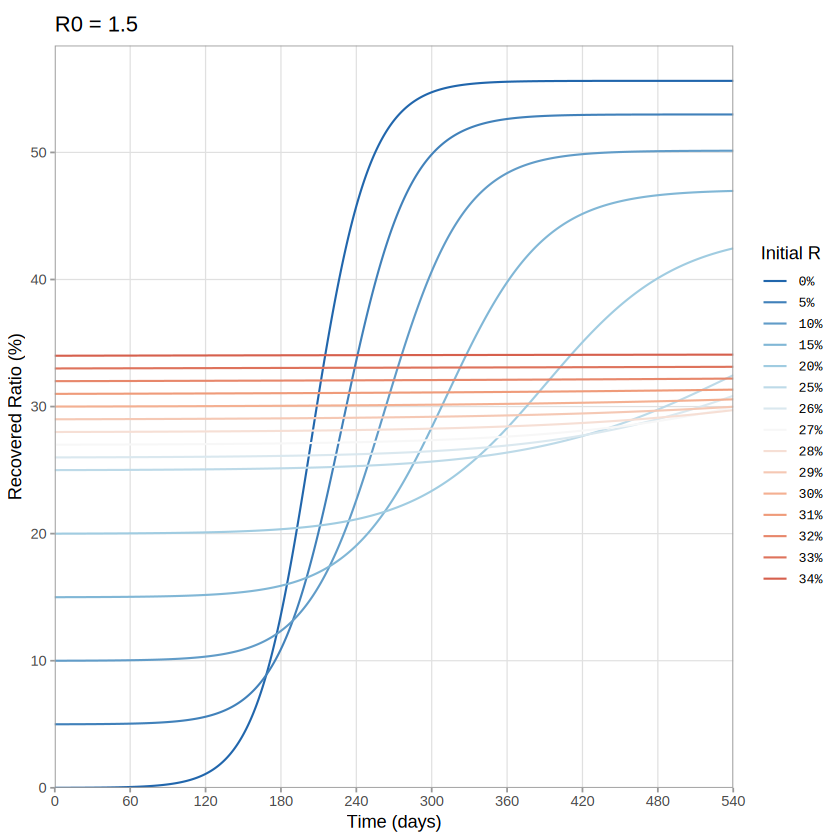

In [36]:
sc <- herd_results$Uncontained
ggplot(sc$df_I, aes(x = time, y = value, colour = label)) +
  geom_line(linewidth = 0.6) +
  scale_colour_manual(values = sc$pal, name = "Initial R") +
  scale_x_continuous(breaks = seq(0, sc$t_end, 60),
                     limits = c(0, sc$t_end), expand = c(0, 0)) +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.05))) +
  labs(title = sc$main_label, x = "Time (days)", y = "Infectious Ratio (%)") +
  theme_mitepid()

sc <- herd_results$Uncontained
ggplot(sc$df_R, aes(x = time, y = value, colour = label)) +
  geom_line(linewidth = 0.6) +
  scale_colour_manual(values = sc$pal, name = "Initial R") +
  scale_x_continuous(breaks = seq(0, sc$t_end, 60),
                     limits = c(0, sc$t_end), expand = c(0, 0)) +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.05))) +
  labs(title = sc$main_label, x = "Time (days)", y = "Recovered Ratio (%)") +
  theme_mitepid()


sc <- herd_results$R0_is_1.5
ggplot(sc$df_I, aes(x = time, y = value, colour = label)) +
  geom_line(linewidth = 0.6) +
  scale_colour_manual(values = sc$pal, name = "Initial R") +
  scale_x_continuous(breaks = seq(0, sc$t_end, 60),
                     limits = c(0, sc$t_end), expand = c(0, 0)) +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.05))) +
  labs(title = sc$main_label, x = "Time (days)", y = "Infectious Ratio (%)") +
  theme_mitepid()


sc <- herd_results$R0_is_1.5
ggplot(sc$df_R, aes(x = time, y = value, colour = label)) +
  geom_line(linewidth = 0.6) +
  scale_colour_manual(values = sc$pal, name = "Initial R") +
  scale_x_continuous(breaks = seq(0, sc$t_end, 60),
                     limits = c(0, sc$t_end), expand = c(0, 0)) +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.05))) +
  labs(title = sc$main_label, x = "Time (days)", y = "Recovered Ratio (%)") +
  theme_mitepid()
